# Decision Tree: A Comprehensive Guide

A Decision Tree is a supervised learning algorithm used for both classification and regression tasks. It works by splitting the dataset into subsets based on the value of input features, creating a tree-like model of decisions.

In this notebook, we'll cover:
1. Basic concepts of Decision Trees
2. Data preparation and visualization
3. Model implementation from scratch
4. Using scikit-learn for Decision Trees
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

Imagine you're playing a game of 20 questions. You ask yes/no questions to narrow down what object someone is thinking of. A Decision Tree works the same way!

The tree starts at a 'root' and at each 'node' it asks a question about a feature (like 'Is petal length > 2.5?'). Based on the answer, it goes left or right down the tree until it reaches a 'leaf' node, which gives the final prediction.

Here's what happens in the code below:
1. We use the famous Iris dataset with flowers and their measurements.
2. We build a decision tree from scratch to understand the splitting logic.
3. We use scikit-learn's optimized implementation for comparison.
4. We visualize the tree and evaluate its performance.

In short: The code teaches you how a tree makes decisions by asking a series of questions about the data.

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

Let's start by importing the necessary libraries:
- NumPy: For numerical computations
- Pandas: For data manipulation
- Matplotlib: For basic plotting
- Seaborn: For statistical visualizations
- Scikit-learn: For machine learning tools

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set the style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll use the famous Iris dataset, which contains measurements for 3 species of iris flowers:
- Setosa
- Versicolor
- Virginica

Features: sepal length, sepal width, petal length, petal width.

Dataset shape: (150, 4)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


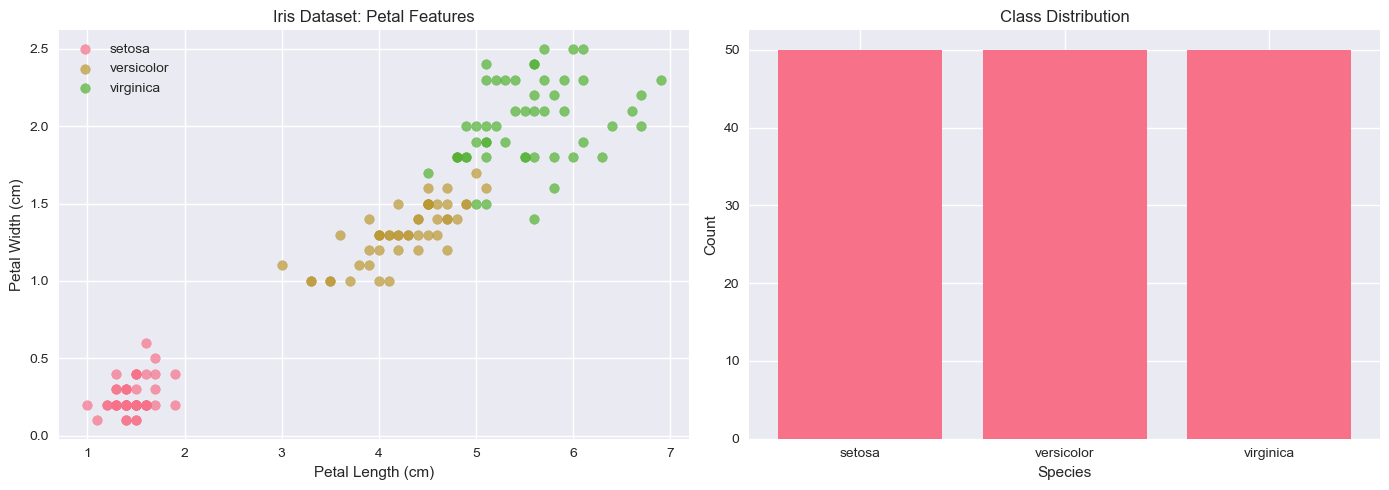

In [3]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Create a DataFrame for visualization
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [class_names[i] for i in y]

print('Dataset shape:', X.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nClass distribution:')
print(df['species'].value_counts())

# Visualize the dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pairplot of two key features
for i, species in enumerate(class_names):
    mask = df['species'] == species
    axes[0].scatter(df[mask]['petal length (cm)'], df[mask]['petal width (cm)'], 
                    label=species, alpha=0.7)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Iris Dataset: Petal Features')
axes[0].legend()

# Class distribution
class_counts = df['species'].value_counts()
axes[1].bar(class_counts.index, class_counts.values)
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Count')
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.show()

# 3. Implementing Decision Tree from Scratch

Key concepts:
1. **Gini Impurity**: Measures how 'impure' a node is. A pure node (all same class) has Gini = 0.
   - Gini = 1 - Σ(pi²)

2. **Information Gain**: How much a split reduces impurity. We pick the split with the highest gain.
   - Gain = Gini(parent) - weighted_average(Gini(children))

3. **Splitting**: At each node, we find the feature and threshold that maximizes information gain.

4. **Stopping criteria**: We stop when max depth is reached or a node is pure.

In [4]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Feature index to split on
        self.threshold = threshold  # Threshold value for split
        self.left = left            # Left child node
        self.right = right          # Right child node
        self.value = value          # Leaf node prediction

class DecisionTreeScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _gini(self, y):
        """Calculate Gini impurity."""
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)

    def _best_split(self, X, y):
        """Find the best feature and threshold to split on."""
        best_gain = -1
        best_feature, best_threshold = None, None
        parent_gini = self._gini(y)
        n_samples, n_features = X.shape

        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                left_gini = self._gini(y[left_mask])
                right_gini = self._gini(y[right_mask])
                weighted_gini = (left_mask.sum() * left_gini + right_mask.sum() * right_gini) / n_samples
                gain = parent_gini - weighted_gini

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        """Recursively build the decision tree."""
        n_samples = len(y)
        n_classes = len(np.unique(y))

        # Stopping criteria
        if depth >= self.max_depth or n_classes == 1 or n_samples < self.min_samples_split:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        best_feature, best_threshold = self._best_split(X, y)

        if best_feature is None:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature=best_feature, threshold=best_threshold, left=left, right=right)

    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    def _predict_sample(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_sample(x, node.left)
        return self._predict_sample(x, node.right)

    def predict(self, X):
        return np.array([self._predict_sample(x, self.root) for x in X])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train scratch model
dt_scratch = DecisionTreeScratch(max_depth=3)
dt_scratch.fit(X_train, y_train)
y_pred_scratch = dt_scratch.predict(X_test)
print(f'Decision Tree (Scratch) Accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}')

Decision Tree (Scratch) Accuracy: 1.0000


# 4. Using Scikit-learn's Decision Tree

Now let's use scikit-learn's optimized implementation and visualize the resulting tree structure.

Decision Tree (Sklearn) Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Tree Structure:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



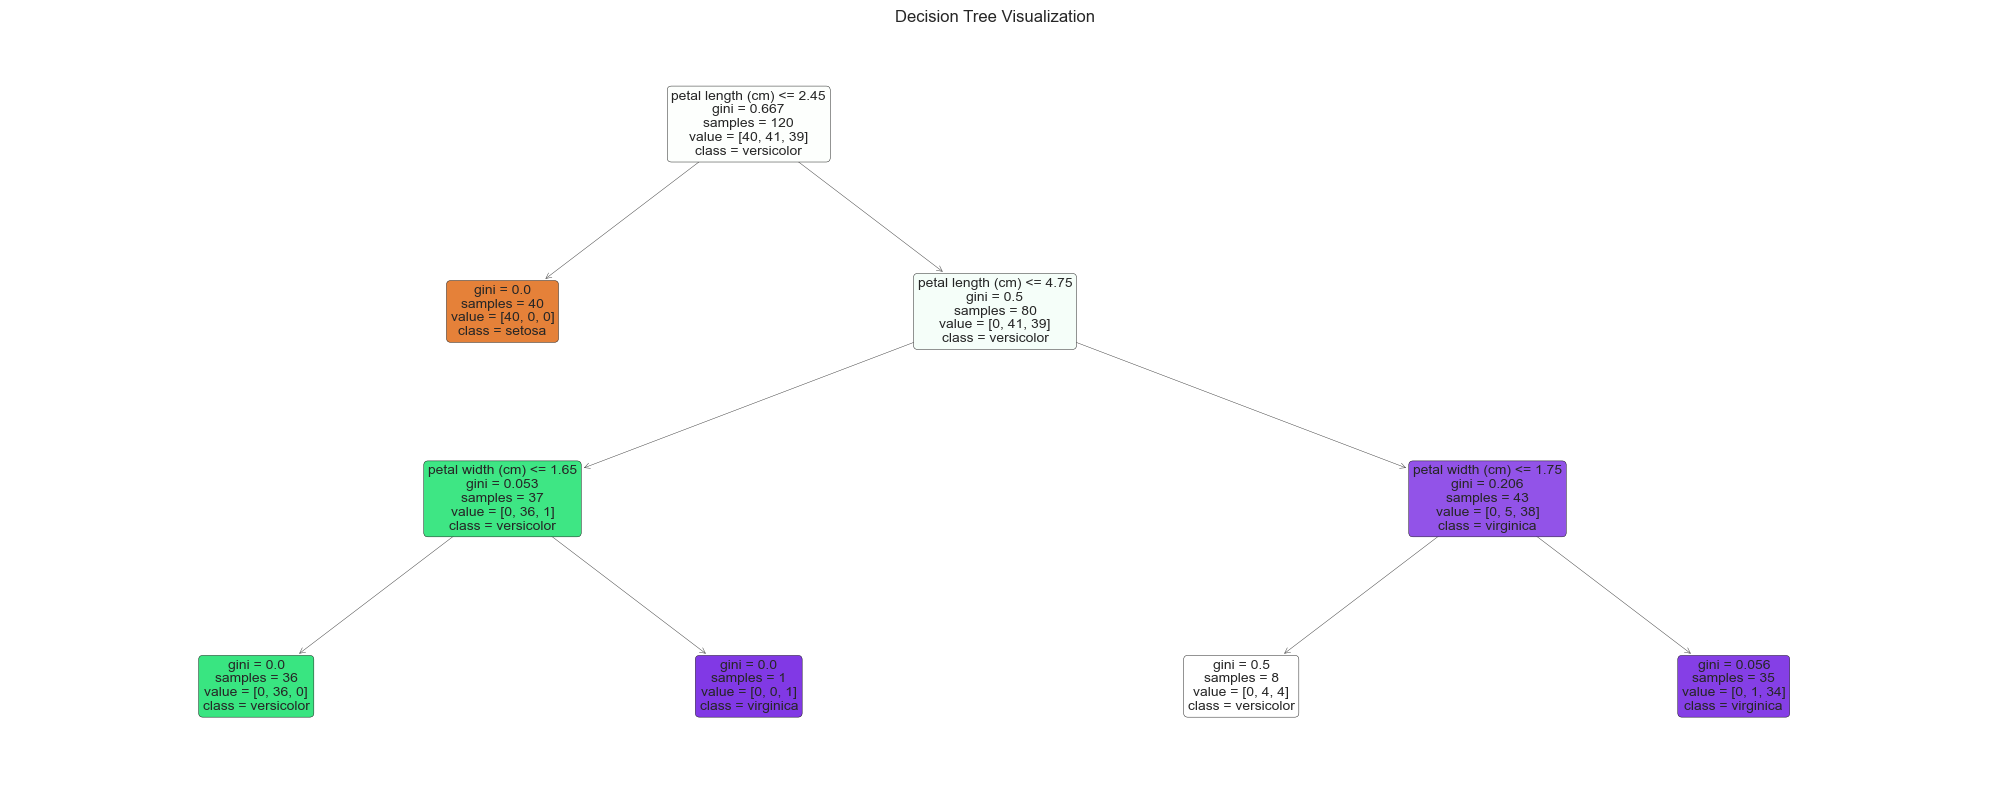

In [5]:
# Train scikit-learn Decision Tree
dt_sklearn = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_sklearn.fit(X_train, y_train)
y_pred_sklearn = dt_sklearn.predict(X_test)

print(f'Decision Tree (Sklearn) Accuracy: {accuracy_score(y_test, y_pred_sklearn):.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_sklearn, target_names=class_names)}')

# Text representation of the tree
print('\nTree Structure:')
print(export_text(dt_sklearn, feature_names=list(feature_names)))

# Visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(dt_sklearn, feature_names=feature_names, class_names=class_names, 
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

# 5. Model Evaluation

Let's evaluate the model with a confusion matrix, feature importances, and explore how tree depth impacts accuracy.

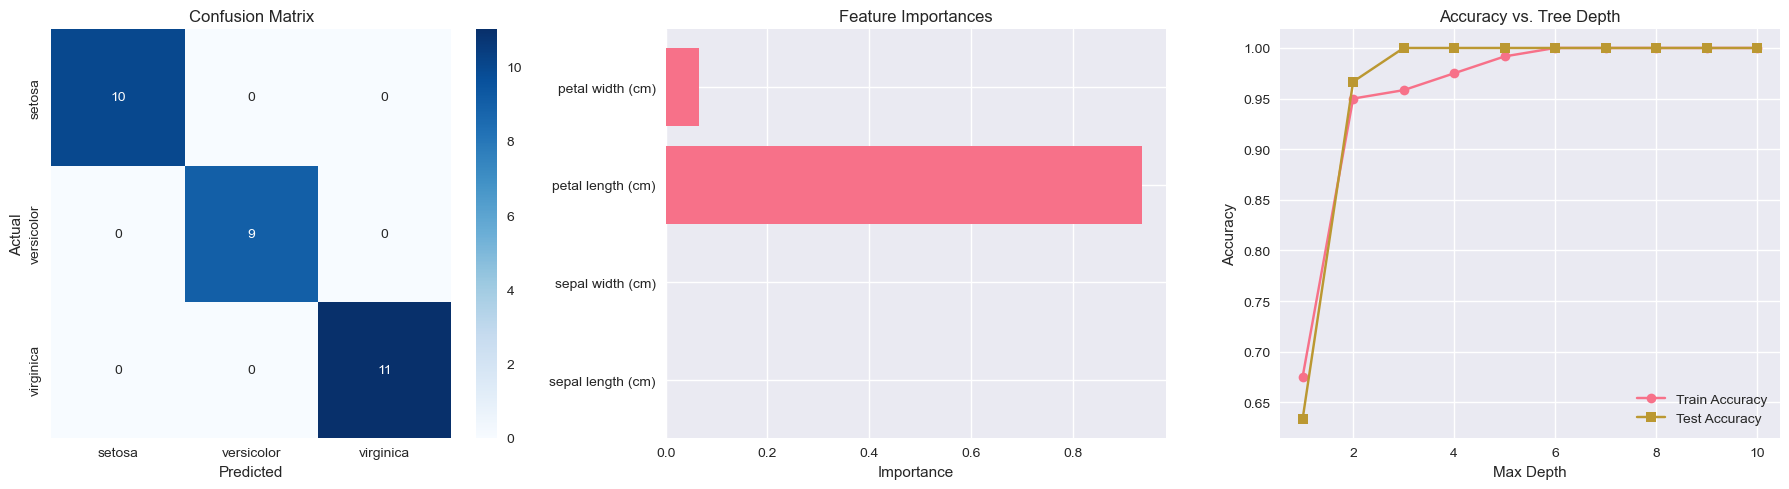


Key Insight: Higher depth → higher training accuracy but may overfit!
Optimal depth appears to be around 3-4 for this dataset.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# 2. Feature Importances
importances = dt_sklearn.feature_importances_
axes[1].barh(feature_names, importances)
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importances')

# 3. Accuracy vs. Max Depth
depths = range(1, 11)
train_accs, test_accs = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))

axes[2].plot(depths, train_accs, label='Train Accuracy', marker='o')
axes[2].plot(depths, test_accs, label='Test Accuracy', marker='s')
axes[2].set_xlabel('Max Depth')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy vs. Tree Depth')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print('\nKey Insight: Higher depth → higher training accuracy but may overfit!')
print(f'Optimal depth appears to be around 3-4 for this dataset.')

# Conclusions and Key Takeaways
Decision Trees are versatile machine learning algorithms that can perform both classification and regression tasks. They construct a tree-like model of decisions based on feature values.
- **Interpretability**: One of the most intuitive and easy-to-explain models.
- **Non-linear Relationships**: Naturally handles non-linear relationships without needing feature transformation.
- **Prone to Overfitting**: Without constraints (like max depth), a tree will perfectly memorize the training data.

# Pros and Cons
**Pros:**
- Highly interpretable and easily visualized.
- Requires very little data preparation (no need to scale or center features).
- Can handle both numerical and categorical data naturally.
- Robust to outliers as splits are based on rank/order rather than absolute values.

**Cons:**
- Exceptionally prone to overfitting (high variance) if not properly pruned.
- Very sensitive to small variations in the training data (a small change can result in a completely different tree).
- Greedy algorithms (like CART) cannot guarantee the globally optimal decision tree.

# 15 Interview Questions and Answers

1. **How does a Decision Tree make splits?**
   *Answer*: It evaluates possible splits for all features and chooses the one that maximizes information gain (or minimizes impurity, like Gini impurity or MSE) at each step.

2. **What is Entropy?**
   *Answer*: A measure of disorder or uncertainty in a dataset. In decision trees, a lower entropy indicates a node is more homogeneous (contains mostly one class).

3. **What is Information Gain?**
   *Answer*: The reduction in entropy after a dataset is split on an attribute. The decision tree algorithm chooses the attribute with the highest Information Gain to split the data.

4. **What is Gini Impurity?**
   *Answer*: A measurement of the likelihood of an incorrect classification of a new instance if it was randomly classified according to the distribution of classes in the node. CART typically uses this over entropy because it is faster to compute (no logarithms).

5. **Why do we need to prune a Decision Tree?**
   *Answer*: Because an unpruned tree will keep splitting until every leaf contains only one sample, resulting in massive overfitting. Pruning restricts the tree's size to improve generalization.

6. **What is the difference between pre-pruning and post-pruning?**
   *Answer*: Pre-pruning stops the tree from growing beyond a certain point (e.g., setting max_depth or min_samples_split). Post-pruning grows a full tree and then removes branches that provide little predictive power (e.g., Cost Complexity Pruning).

7. **Do Decision Trees require feature scaling?**
   *Answer*: No. Decision trees make splits based on relative ordering of feature values, not their absolute scale, so standardization or normalization is completely unnecessary.

8. **How do Decision Trees handle categorical variables?**
   *Answer*: Some implementations (like standard sklearn) require one-hot encoding categorical variables, while others (like H2O or R's rpart) can partition categorical categories natively without one-hot encoding.

9. **Why are Decision Trees considered "greedy" algorithms?**
   *Answer*: Because they make the locally optimal choice at each node in the hope of finding the global optimum. They don't look ahead to see if a slightly worse split now might lead to an exponentially better split down the line.

10. **How do Decision Trees handle missing values natively?**
    *Answer*: Standard implementations like scikit-learn's CART do not handle them natively and require imputation. However, algorithms like C4.5 and XGBoost can handle them using surrogate splits or default directions.

11. **What is a Random Forest and how does it relate to Decision Trees?**
    *Answer*: An ensemble method that trains many decision trees on bootstrapped subsets of the data and random subsets of features. It solves the high variance problem of single decision trees.

12. **What are the hyperparameters you can tune to prevent overfitting in a Decision Tree?**
    *Answer*: `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `ccp_alpha` for post-pruning.

13. **Can a decision tree find linear combinations of features?**
    *Answer*: No. Standard decision trees make orthogonal (axis-parallel) splits. If the optimal decision boundary is diagonal (e.g., x + y > 0), a decision tree has to approximate it with multiple zig-zag stepwise splits.

14. **How does a Regression Tree differ from a Classification Tree?**
    *Answer*: Instead of predicting a discrete class based on majority vote in the leaf, a regression tree predicts a continuous value by taking the average (mean) of the target values in the leaf node. It splits based on reducing MSE or MAE rather than Gini impurity.

15. **What is the runtime complexity to train a Decision Tree?**
    *Answer*: Assuming N samples and M features, sorting all features takes O(M * N log N). Building the entire tree has an average complexity of roughly O(M * N * log(N)), but worst-case depth can be O(N).
